In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
print("Loading MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

In [5]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [4]:
y

array([5, 0, 4, ..., 4, 5, 6])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_test_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [60]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs' , 'saga'],
    'max_iter': [500]
}

In [61]:
n_classes = 10

meta_train = np.zeros(
    (X_train_scaled.shape[0], n_classes)
)

meta_test = np.zeros(
    (X_test_scaled.shape[0], n_classes)
)

best_models = {}
best_params = {}

In [62]:
outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for digit in range(10):

    print("\n" + "="*60)
    print(f"Training model for Digit {digit} vs Rest")
    print("="*60)

    y_binary = (y_train == digit).astype(int)

    # Hyperparameter tuning
    grid = GridSearchCV(
        LogisticRegression(),
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=3
    )

    grid.fit(X_train_scaled, y_binary)

    best_model = grid.best_estimator_

    best_models[digit] = best_model
    best_params[digit] = grid.best_params_

    print("Best Params:", grid.best_params_)

     
    # OOF Predictions (for stacking)
    oof_probs = cross_val_predict(
        best_model,
        X_train_scaled,
        y_binary,
        cv=outer_cv,
        method="predict_proba",
        n_jobs=3
    )[:, 1]

    meta_train[:, digit] = oof_probs

    # Train final model
    best_model.fit(X_train_scaled, y_binary)

    # Binary accuracy
    y_train_pred = best_model.predict(X_train_scaled)

    binary_acc = accuracy_score(y_binary, y_train_pred)

    print("Binary Accuracy:", binary_acc)
    # Test probabilities
    test_probs = best_model.predict_proba(X_test_scaled)[:, 1]
    meta_test[:, digit] = test_probs


Training model for Digit 0 vs Rest


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


KeyboardInterrupt: 

In [47]:
print("Meta train shape:", meta_train.shape)
print("Meta test shape:", meta_test.shape)

Meta train shape: (56000, 10)
Meta test shape: (14000, 10)


In [49]:
meta_model = LogisticRegression( solver='saga', max_iter=1000, tol=0.1)
meta_model.fit(meta_train, y_train)

LogisticRegression(max_iter=1000, solver='saga', tol=0.1)

In [50]:
y_pred = meta_model.predict(meta_test)

In [51]:
y_pred

array([7, 3, 1, ..., 6, 2, 8])

In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.916


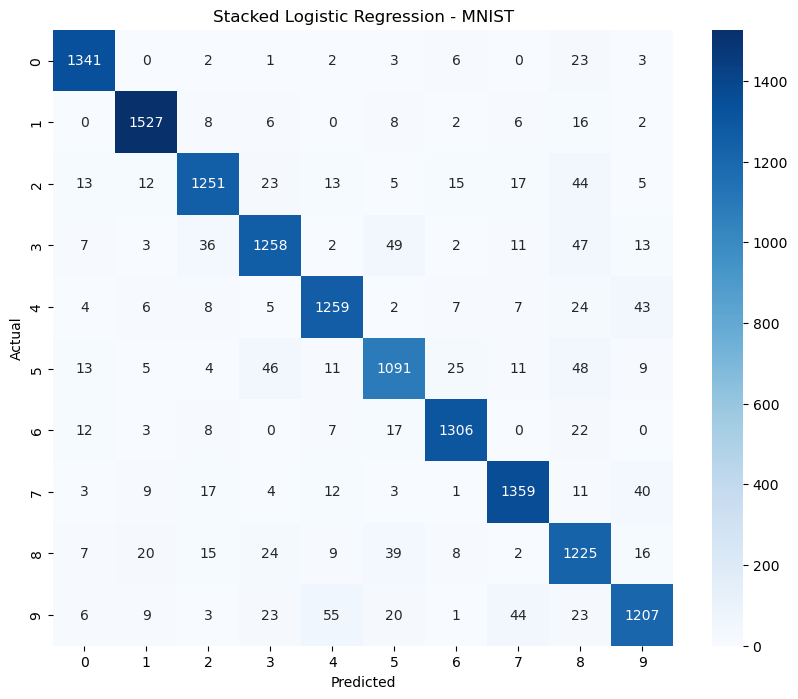

In [53]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Stacked Logistic Regression - MNIST")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
for i in range(10):
    print(f"Image {i} → Predicted Digit: {y_pred[i]}")

Image 0 → Predicted Digit: 7
Image 1 → Predicted Digit: 3
Image 2 → Predicted Digit: 1
Image 3 → Predicted Digit: 1
Image 4 → Predicted Digit: 2
Image 5 → Predicted Digit: 5
Image 6 → Predicted Digit: 9
Image 7 → Predicted Digit: 3
Image 8 → Predicted Digit: 8
Image 9 → Predicted Digit: 1


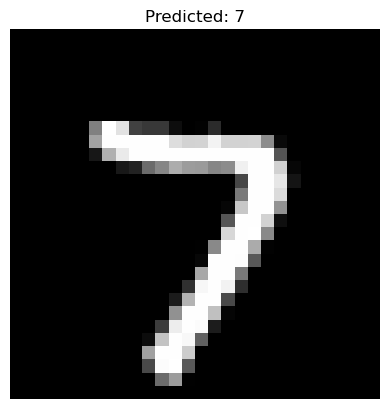

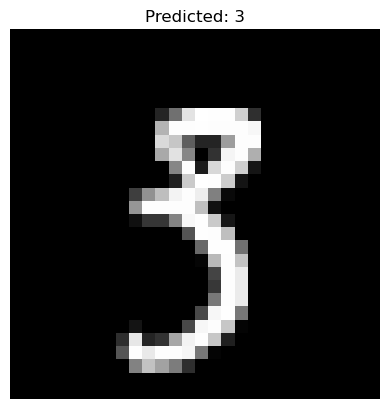

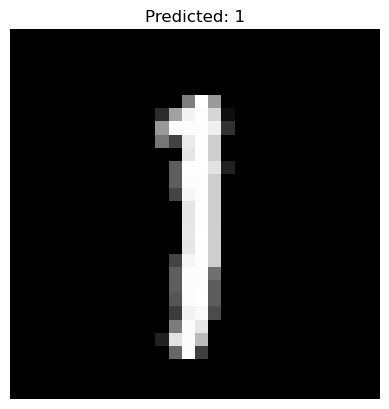

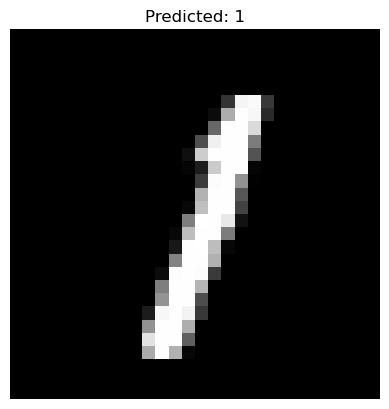

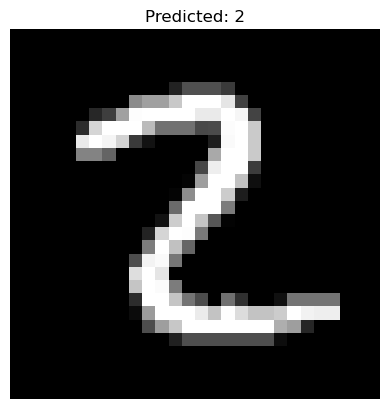

In [55]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis("off")
    plt.show()

In [56]:
import numpy as np

def predict_digit_with_confidence(
    image_28x28,
    scaler,
    best_models,
    meta_model
):
    """
    Predict digit and confidence using stacked model.
    """

    # Flatten image
    x = image_28x28.reshape(1, -1).astype(np.float32)
   
     
    # Scale
    x_scaled = scaler.transform(x)

    # Generate meta-features
    meta_features = np.zeros((1, 10))

    for digit in range(10):
        prob = best_models[digit].predict_proba(x_scaled)[0, 1]
        meta_features[0, digit] = prob

    # Final prediction probabilities
    class_probs = meta_model.predict_proba(meta_features)[0]

    predicted_digit = np.argmax(class_probs)
    confidence = class_probs[predicted_digit]


    return {
        "digit": int(predicted_digit),
        "confidence": float(confidence),
        "all_probabilities": class_probs
    }

In [32]:
from PIL import Image
import numpy as np

def predict_digit_from_file(
    image_path,
    scaler,
    best_models,
    meta_model
):
    img = Image.open(image_path).convert("L")

    img = img.resize((28, 28))

    img_array = np.array(img)

    # Optional: invert colors if digit is black on white background
    img_array = 255 - img_array

    plt.figure(figsize=(3, 3))
    plt.imshow(img_array, cmap="gray")
    plt.title("Model Input (After Inversion)")
    plt.axis("off")
    plt.show()

    pred = predict_digit_with_confidence(
        img_array,
        scaler,
        best_models,
        meta_model
    )

    return pred

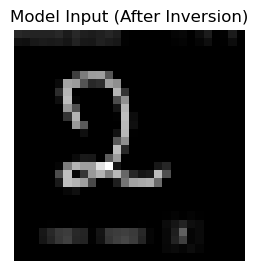

Predicted Digit: {'digit': 5, 'confidence': 0.9451220689674599, 'all_probabilities': array([2.48905974e-03, 1.34005766e-05, 3.06566913e-04, 3.50839129e-02,
       1.50658609e-07, 9.45122069e-01, 1.68745164e-02, 1.07480725e-04,
       1.66690584e-06, 1.17623681e-06])}


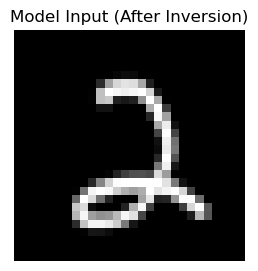

Predicted Digit: {'digit': 2, 'confidence': 0.9630794091030547, 'all_probabilities': array([9.06493407e-04, 2.12491404e-03, 9.63079409e-01, 1.55080880e-02,
       5.60200113e-04, 9.11740237e-03, 5.74570738e-03, 2.23715218e-03,
       6.42377997e-04, 7.82554033e-05])}


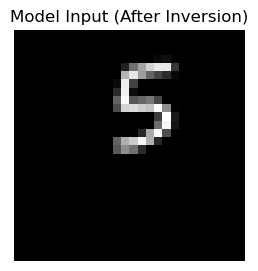

Predicted Digit: {'digit': 3, 'confidence': 0.25187083206579336, 'all_probabilities': array([0.0147365 , 0.05660439, 0.16742871, 0.25187083, 0.03911521,
       0.08057033, 0.01998992, 0.1121801 , 0.15218869, 0.10531531])}


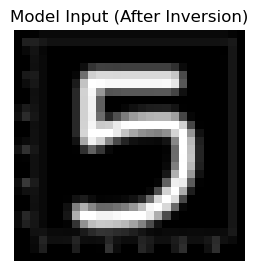

Predicted Digit: {'digit': 7, 'confidence': 0.818723835535885, 'all_probabilities': array([8.55057697e-03, 6.51302658e-02, 2.41370885e-02, 2.28982657e-02,
       1.42799022e-02, 3.94540373e-02, 5.35654193e-03, 8.18723836e-01,
       2.33760102e-05, 1.44611002e-03])}


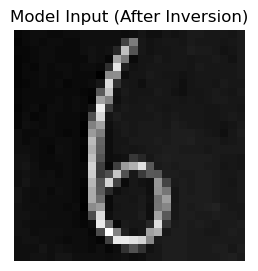

Predicted Digit: {'digit': 5, 'confidence': 0.8056497916528433, 'all_probabilities': array([1.64193686e-03, 1.10608386e-01, 1.62707614e-03, 6.93395421e-03,
       7.91100938e-04, 8.05649792e-01, 5.42445521e-03, 6.72524012e-02,
       2.00008370e-06, 6.88974459e-05])}


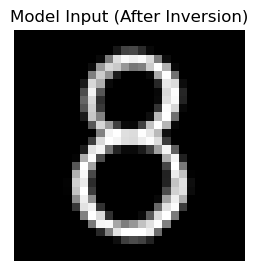

Predicted Digit: {'digit': 3, 'confidence': 0.8608315992865869, 'all_probabilities': array([0.00153838, 0.00243809, 0.02168033, 0.8608316 , 0.00464546,
       0.03472854, 0.00093935, 0.0035949 , 0.0438911 , 0.02571224])}


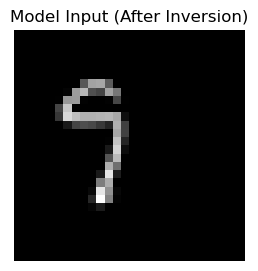

Predicted Digit: {'digit': 5, 'confidence': 0.9775788774319302, 'all_probabilities': array([1.40289176e-03, 6.64954723e-04, 7.87162158e-04, 5.28188344e-03,
       1.62817560e-04, 9.77578877e-01, 1.11253552e-02, 5.74321026e-04,
       1.86390113e-03, 5.57835592e-04])}


In [57]:
image_array = [
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/two.png", 
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/two2.png", 
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/five.png",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/five2.png",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/six.jpeg",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/eight.png",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/nine.jpg",
]

for img in image_array:
    pred = predict_digit_from_file(img,
    scaler,
    best_models,
    meta_model
    ) 
    print("Predicted Digit:", pred)

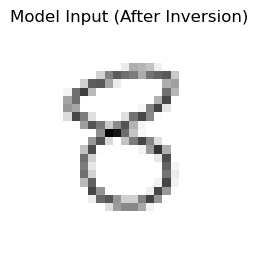

Predicted Digit: {'digit': 5, 'confidence': 0.8056497916528426, 'all_probabilities': array([1.64193686e-03, 1.10608386e-01, 1.62707614e-03, 6.93395421e-03,
       7.91100938e-04, 8.05649792e-01, 5.42445521e-03, 6.72524012e-02,
       2.00008370e-06, 6.88974459e-05])}


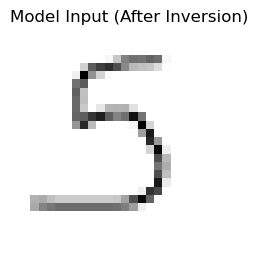

Predicted Digit: {'digit': 5, 'confidence': 0.8056497916528426, 'all_probabilities': array([1.64193686e-03, 1.10608386e-01, 1.62707614e-03, 6.93395421e-03,
       7.91100938e-04, 8.05649792e-01, 5.42445521e-03, 6.72524012e-02,
       2.00008370e-06, 6.88974459e-05])}


In [58]:
#minst_data

image_array = [
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/blk_background/eight.jpg",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/blk_background/five.jpg"
]

for img in image_array:
    pred = predict_digit_from_file(img,
    scaler,
    best_models,
    meta_model
    ) 
    print("Predicted Digit:", pred)